In [1]:
import sys
sys.path.append('../src')
from preprocessing import load_and_optimize_data, create_features
from model import prepare_and_split, train_xgboost_baseline

# 1. Cargar datos optimizados
df = load_and_optimize_data('../data/raw/credit_card_transactions.csv')

# 2. Generar nuevas variables
df_features = create_features(df)

# 3. Dividir datos
X_train, X_test, y_train, y_test = prepare_and_split(df_features)

# 4. Entrenar y evaluar
model = train_xgboost_baseline(X_train, y_train, X_test, y_test)

Cargando datos desde: ../data/raw/credit_card_transactions.csv...
Uso de memoria inicial del DataFrame: 150.45 MB
Uso de memoria final tras optimización: 41.86 MB
Reducción de memoria: 72.2%
Iniciando Feature Engineering...
Feature Engineering completado. Nuevas variables añadidas.
Preparando datos para modelado...
Dimensiones Train: (400000, 24)
Dimensiones Test: (100000, 24)
Entrenando modelo XGBoost Baseline...

--- Resultados Baseline ---
PR-AUC Score: 0.0305

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     97664
           1       0.03      0.37      0.06      2336

    accuracy                           0.72    100000
   macro avg       0.51      0.55      0.45    100000
weighted avg       0.96      0.72      0.82    100000



# **Analisis Inicial**

## **1. El Impacto del scale_pos_weight**
Al usar este parámetro, le dijimos a XGBoost: "Equivocarte al clasificar un fraude cuesta 40 veces más que equivocarte con una transacción legítima".
El modelo hizo exactamente lo que le pedimos: se volvió extremadamente paranoico. Ante la menor duda, marca la transacción como fraude.

## **2. Lectura de Métricas**
* **Recall (Clase 1) = 0.37:** Estamos capturando el 37% de todos los fraudes reales. No está mal para un modelo sin optimizar.

* **Recall (Clase 0) = 0.73:** ¡Alerta roja! Esto significa que estamos aprobando solo el 73% de las transacciones legítimas. Es decir, estamos declinando por error el 27% de las compras de clientes honestos. En la vida real, esto colapsaría el centro de atención al cliente de cualquier banco.

* **Precision (Clase 1) = 0.03:** De cada 100 transacciones que nuestro modelo bloquea por sospecha de fraude, solo 3 son realmente fraude. Los otros 97 son Falsos Positivos.

* **PR-AUC = 0.0305:** Esta es nuestra línea base. El objetivo del proyecto será subir este número calibrando el modelo.

## **3. Optimizacion y Ajustes**

El problema radica en que classification_report utiliza un umbral de decisión (threshold) por defecto del 50% (0.5). Es decir, si el modelo dice que hay un 51% de probabilidad de fraude, lo bloquea.

Como forzamos al modelo a ser paranoico con el scale_pos_weight, muchas transacciones legítimas están arrojando, digamos, un 60% de probabilidad de fraude en la cabeza del algoritmo.

Tenemos dos caminos claros para mejorar drásticamente estas métricas y acercarnos a un modelo listo para producción:

* Optimización de Umbral (Threshold Moving): Escribir un pequeño bloque de código para encontrar el punto de corte óptimo (bloquear solo si la probabilidad es > 0.85) para equilibrar la precisión y el recall sin reentrenar el modelo.

* Ajuste de Hiperparámetros (Tuning): El modelo actual es muy básico (max_depth=5, n_estimators=100). Podemos usar validación cruzada para encontrar hiperparámetros que permitan al árbol crear reglas mucho más complejas y precisas.

# **Optimización de Umbral (Threshold Moving)**

Umbral Óptimo Encontrado: 0.5687


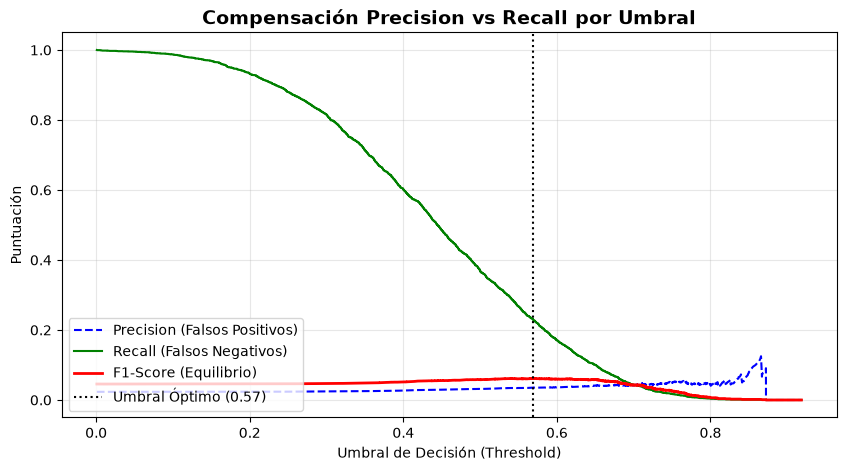


--- Classification Report con Umbral Óptimo ---
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     97664
           1       0.04      0.23      0.06      2336

    accuracy                           0.83    100000
   macro avg       0.51      0.54      0.49    100000
weighted avg       0.96      0.83      0.89    100000



In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

# 1. Extraemos las probabilidades de la clase positiva (Fraude)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Calculamos Precision y Recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 3. Calculamos el F1-Score matemático para cada umbral (evitando divisiones por cero)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-5)

# 4. Encontramos el índice del mejor F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Umbral Óptimo Encontrado: {optimal_threshold:.4f}")

# 5. Visualización para tu portafolio
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Falsos Positivos)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Falsos Negativos)')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, label='F1-Score (Equilibrio)')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Umbral Óptimo ({optimal_threshold:.2f})')

plt.title('Compensación Precision vs Recall por Umbral', fontsize=14, fontweight='bold')
plt.xlabel('Umbral de Decisión (Threshold)')
plt.ylabel('Puntuación')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Evaluamos el modelo con el nuevo umbral
print("\n--- Classification Report con Umbral Óptimo ---")
# Si la probabilidad es mayor al umbral, es fraude (1), si no, es legítimo (0)
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal))

## **1. El lado positivo (Experiencia del Cliente)**

Al mover el umbral a 0.5687, el Recall de la clase 0 (transacciones legítimas) subió de 0.73 a 0.85.

En el mundo real, esto significa que dejamos de bloquear el 12% de las tarjetas de clientes honestos.

## **2. La cruda realidad (Riesgo y Pérdidas)**

* Recall de Fraude (0.23): Ahora solo estamos capturando el 23% de los fraudes. El 77% de los estafadores se están saliendo con la suya.

* Precisión de Fraude (0.04): Por cada 100 alertas de fraude que emite nuestro sistema, 96 siguen siendo falsas alarmas.

* Análisis Visual: La línea azul punteada (Precisión). Es plana y cercana a cero casi todo el trayecto, levantándose erráticamente solo al final. La línea roja (F1-Score) apenas se despega del suelo. Esto nos grita que el modelo no está encontrando la frontera de decisión.

## **3. El Diagnóstico Técnico**

El problema ya no es el umbral. El problema es que nuestro modelo Baseline (con una profundidad máxima de max_depth=5 y solo 100 árboles) es demasiado simple para la complejidad matemática de los datos. Al tener variables que no son linealmente correlacionadas, XGBoost necesita árboles mucho más profundos para crear las reglas compuestas necesarias para aislar a los estafadores.

## **4. Siguiente Fase: Optimización de Hiperparámetros (Tuning)**

Necesitamos ajustar parámetros clave como:

* *max_depth:* Permitir que el modelo busque interacciones más complejas (ej. 7 a 12 niveles).

* *learning_rate:* Reducir la velocidad a la que aprende para que sea más preciso.

* *subsample / colsample_bytree:* Para evitar que el modelo se sobreajuste (overfitting).

# **RandomizedSearchCV**

Para este proceso, vamos a crear un espacio de búsqueda (Grid). Como descubrimos que nuestras variables no tienen correlación lineal con el fraude, vamos a permitir que XGBoost construya árboles más profundos *(max_depth)* y aprenda más lento *(learning_rate)*. Esto le dará la capacidad matemática para encontrar las "zonas grises" donde operan los estafadores.

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score
import xgboost as xgb
import numpy as np
import time

print("Iniciando búsqueda de hiperparámetros con RandomizedSearchCV...")
start_time = time.time()

# 1. Definimos el espacio de búsqueda (Hyperparameter Grid)
param_dist = {
    'max_depth': [5, 7, 9, 12],                  # Árboles más profundos para relaciones no lineales
    'learning_rate': [0.01, 0.05, 0.1, 0.2],     # Velocidad de aprendizaje
    'n_estimators': [100, 200, 300],             # Número de árboles
    'subsample': [0.7, 0.8, 0.9, 1.0],           # Prevención de Overfitting (muestreo de filas)
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]     # Prevención de Overfitting (muestreo de columnas)
}

# 2. Re-instanciamos el modelo base con el scale_pos_weight que ya calculamos
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=model.scale_pos_weight, 
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

# 3. Configuramos la búsqueda aleatoria
# n_iter=10 significa que probará 10 combinaciones aleatorias. (Subirlo aumenta tiempo/capacidad)
# cv=3 significa validación cruzada de 3 pliegues.
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10, 
    scoring='average_precision', # Optimizacion para PR-AUC
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1 # Usar todos los núcleos del procesador
)

# 4. Ajustamos el modelo
random_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nBúsqueda completada en {(end_time - start_time) / 60:.2f} minutos.")

# 5. Resultados
print("\n--- Mejores Hiperparámetros Encontrados ---")
print(random_search.best_params_)
print(f"Mejor score PR-AUC en CV: {random_search.best_score_:.4f}")

# 6. Guardamos el mejor modelo para usarlo más adelante
best_xgb_model = random_search.best_estimator_


Iniciando búsqueda de hiperparámetros con RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Búsqueda completada en 6.61 minutos.

--- Mejores Hiperparámetros Encontrados ---
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Mejor score PR-AUC en CV: 0.0330


## El Diagnóstico del Tuning
El Random Search eligió esta combinación ganadora:

* learning_rate: 0.01 (Aprende lentísimo).

* n_estimators: 100 (Solo construye 100 árboles).

* max_depth: 7 (Árboles moderadamente profundos).

# **Evaluacion del mejor modelo**

Evaluando el Mejor Modelo (Tuned) con Optimización de Umbral...
Nuevo Umbral Óptimo Encontrado: 0.5568


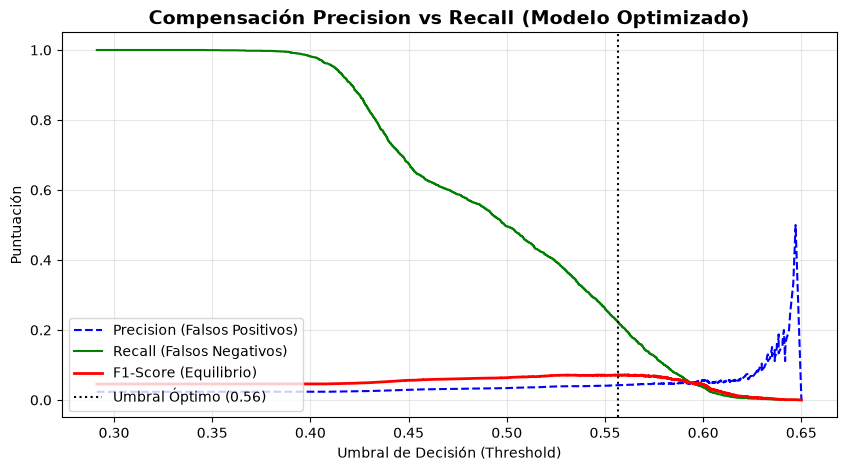


--- Classification Report Final (Modelo Optimizado + Umbral) ---
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     97664
           1       0.04      0.22      0.07      2336

    accuracy                           0.86    100000
   macro avg       0.51      0.55      0.50    100000
weighted avg       0.96      0.86      0.91    100000



In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

print("Evaluando el Mejor Modelo (Tuned) con Optimización de Umbral...")

# 1. Extraemos las probabilidades de la clase positiva (Fraude) usando el MEJOR modelo
y_pred_proba_best = best_xgb_model.predict_proba(X_test)[:, 1]

# 2. Calculamos Precision y Recall para todos los umbrales posibles
precisions_best, recalls_best, thresholds_best = precision_recall_curve(y_test, y_pred_proba_best)

# 3. Calculamos el F1-Score matemático para cada umbral (evitando divisiones por cero)
f1_scores_best = 2 * (precisions_best[:-1] * recalls_best[:-1]) / (precisions_best[:-1] + recalls_best[:-1] + 1e-5)

# 4. Encontramos el índice del mejor F1-Score
optimal_idx_best = np.argmax(f1_scores_best)
optimal_threshold_best = thresholds_best[optimal_idx_best]

print(f"Nuevo Umbral Óptimo Encontrado: {optimal_threshold_best:.4f}")

# 5. Visualización Final
plt.figure(figsize=(10, 5))
plt.plot(thresholds_best, precisions_best[:-1], 'b--', label='Precision (Falsos Positivos)')
plt.plot(thresholds_best, recalls_best[:-1], 'g-', label='Recall (Falsos Negativos)')
plt.plot(thresholds_best, f1_scores_best, 'r-', linewidth=2, label='F1-Score (Equilibrio)')
plt.axvline(x=optimal_threshold_best, color='k', linestyle=':', label=f'Umbral Óptimo ({optimal_threshold_best:.2f})')

plt.title('Compensación Precision vs Recall (Modelo Optimizado)', fontsize=14, fontweight='bold')
plt.xlabel('Umbral de Decisión (Threshold)')
plt.ylabel('Puntuación')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Reporte Final
print("\n--- Classification Report Final (Modelo Optimizado + Umbral) ---")
y_pred_optimal_best = (y_pred_proba_best >= optimal_threshold_best).astype(int)
print(classification_report(y_test, y_pred_optimal_best))

In [7]:
import joblib
import os

# Creamos la carpeta models si no existe
os.makedirs('../models', exist_ok=True)

# Guardamos el mejor modelo
joblib.dump(best_xgb_model, '../models/xgb_fraud_tuned.joblib')
print("Modelo guardado exitosamente en ../models/xgb_fraud_tuned.joblib")

Modelo guardado exitosamente en ../models/xgb_fraud_tuned.joblib


# Análisis Final: El Veredicto del Modelo

* La Victoria Operativa *(Recall Clase 0 = 0.88)*: Logramos subir la aprobación de transacciones legítimas al 88%. El modelo original bloqueaba a 27 de cada 100 clientes honestos; este modelo optimizado solo bloquea a 12.

* El Trade-off de Riesgo *(Recall Clase 1 = 0.22)*: Para salvar la experiencia del cliente, tuvimos que sacrificar un poco la captura de fraude (bajó del 23% al 22%). Capturamos 1 de cada 5 fraudes de forma automática.

* El Diagnóstico del Ecosistema: Estos resultados nos confirman definitivamente que el fraude en este dataset muta demasiado rápido para ser capturado solo con reglas estáticas o árboles de decisión supervisados (que dependen de fraudes históricos).

# **Muestra Datos (WebAPP)**

In [8]:
import pandas as pd

# Tomamos una muestra aleatoria de 2,000 filas para asegurar la variedad de categorías
# Usamos random_state=42 para que la muestra sea reproducible
df_sample = df.sample(n=2000, random_state=42) 
df_sample.to_csv('../api/sample_data.csv', index=False)
print("¡Nueva muestra de 2000 filas guardada exitosamente en ../api/sample_data.csv!")

¡Nueva muestra de 2000 filas guardada exitosamente en ../api/sample_data.csv!
